# ALBEF Model Test Results — BNS/NSBH Classification

Results from: `Model/eval_results/bns_nsbh_test_v8/eval_results.json`

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

In [2]:
import os
_BASE = os.environ.get('BASE_DIR', '/fred/oz016/bgao_kn')

EVAL_DIR = Path('../Model/eval_results/cls_test/bns_nsbh_test_full')
OUT_DIR = Path(f"{_BASE}/gw-kn-multimodal/figures")
SAVE_DIR = OUT_DIR / "test_results"  # save plots alongside results


with open(EVAL_DIR / 'eval_results.json') as f:
    results = json.load(f)

print(json.dumps(results['classification_by_source'], indent=2))

{
  "bns": {
    "metrics": {
      "n_dropped_nonfinite": 0,
      "auroc": 0.9719359874725342,
      "auprc": 0.9220150113105774,
      "f1_optimal": 0.8666831851005554,
      "f1_threshold": 0.3199999928474426,
      "ece": 0.022094414687958797,
      "tp": 4874,
      "fp": 634,
      "tn": 15679,
      "fn": 1035,
      "accuracy": 0.9248942489424894,
      "precision": 0.8848946986201888,
      "recall": 0.8248434591301405,
      "f1": 0.8538144871682578,
      "precision_confusion": 0.8848946986201888,
      "recall_confusion": 0.8248434591301405,
      "f1_confusion": 0.8538144871682578
    },
    "pair_type_counts": {
      "n_total": 22222,
      "n_positive": 5909,
      "n_optical_neg": 5909,
      "n_gw_neg": 4454,
      "n_hard_neg": 5950
    }
  },
  "nsbh": {
    "metrics": {
      "n_dropped_nonfinite": 0,
      "auroc": 0.940352201461792,
      "auprc": 0.8335839509963989,
      "f1_optimal": 0.7934892773628235,
      "f1_threshold": 0.23999999463558197,
      "ece": 

## Confusion Matrices — BNS and NSBH

In [3]:
def plot_confusion_matrix(
    ax, tp, fp, tn, fn,
    title, metrics=None,
    cmap='Blues', normalize=True
):
    """
    Plot a 2x2 confusion matrix on ax.

    Layout (scikit-learn convention):
        rows = actual label, cols = predicted label
        [[TN, FP],
         [FN, TP]]
    """
    cm_raw = np.array([[tn, fp],
                        [fn, tp]], dtype=float)

    if normalize:
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        cm_plot = cm_raw / row_sums
    else:
        cm_plot = cm_raw

    im = ax.imshow(cm_plot, interpolation='nearest', cmap=cmap,
                   vmin=0, vmax=1 if normalize else None)

    # 获取 colorbar 对象并设置刻度数字大小
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=16)

    labels = ['Negative', 'Positive']
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=16)
    ax.set_yticklabels(labels, fontsize=16)
    ax.set_xlabel('Predicted label', fontsize=18)
    ax.set_ylabel('True label', fontsize=18)

    thresh = cm_plot.max() / 2.0
    for i in range(2):
        for j in range(2):
            val = cm_plot[i, j]
            txt = f'{val:.1%}' if normalize else f'{val:.0f}'
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=16, color=color, fontweight='bold')

    subtitle = ''
    if metrics is not None:
        prec = metrics.get('precision_confusion', metrics['tp'] / (metrics['tp'] + metrics['fp']))
        rec  = metrics.get('recall_confusion',    metrics['tp'] / (metrics['tp'] + metrics['fn']))
        f1   = metrics.get('f1_confusion',        2 * prec * rec / (prec + rec))
        auroc = metrics['auroc']
        # subtitle = (f'AUROC={auroc:.3f}  |  '
        #             f'Precision={prec:.3f}  |  '
        #             f'Recall={rec:.3f}  |  '
        #             f'F1={f1:.3f}')


def add_panel_labels_below(axes, fontsize=18):
    for idx, ax in enumerate(np.atleast_1d(axes).ravel()):
        if not ax.axison:
            continue
        ax.text(0.5, -0.20, f"({chr(ord('a') + idx)})", transform=ax.transAxes, ha="center", va="top", fontsize=fontsize, clip_on=False)



Saved → /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_bns_nsbh.pdf


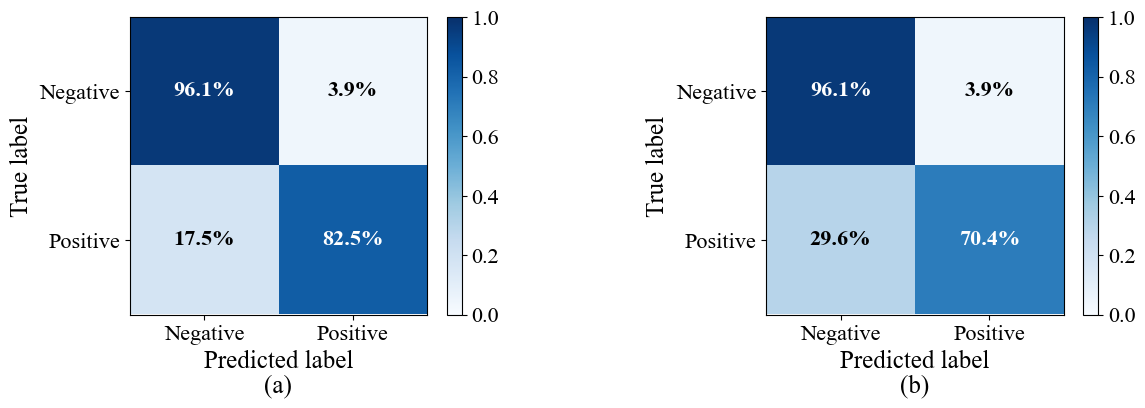

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, source in zip(axes, ['bns', 'nsbh']):
    m = results['classification_by_source'][source]['metrics']
    plot_confusion_matrix(
        ax,
        tp=m['tp'], fp=m['fp'], tn=m['tn'], fn=m['fn'],
        title='',
        metrics=m,
        normalize=True,
    )

add_panel_labels_below(axes, fontsize=18)
plt.tight_layout(rect=(0, 0.08, 1, 1))
save_path = SAVE_DIR / 'confusion_matrix_bns_nsbh.pdf'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## Combined overview — all pairs

Saved → /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_all.png


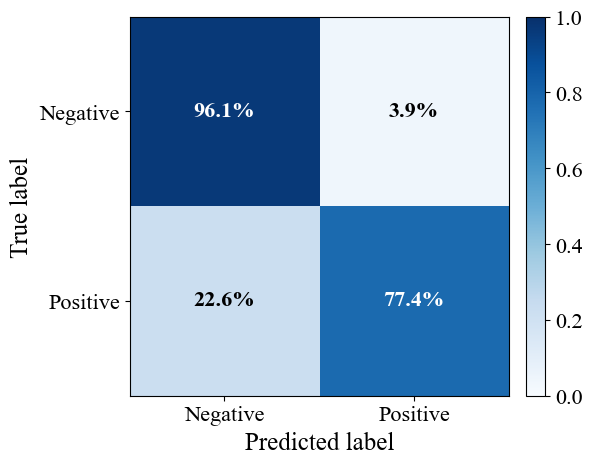

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

m = results['classification']
plot_confusion_matrix(
    ax,
    tp=m['tp'], fp=m['fp'], tn=m['tn'], fn=m['fn'],
    title='',
    metrics=m,
    normalize=True,
)

plt.tight_layout()
save_path = SAVE_DIR / 'confusion_matrix_all.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()